<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Line Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas


In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


--2026-01-21 21:26:21--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  64.4MB/s    in 2.4s    

2026-01-21 21:26:23 (64.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



#### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

#### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

#### Display the first few rows to understand the structure of the data


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


In [8]:
# 1. Prepare and clean data
# Most 2026 surveys use ranges like '18-24 years old', '25-34 years old', etc.
df_AgeComp = df[['Age', 'ConvertedCompYearly']].dropna()

In [9]:
# 2. Group by Age and calculate Median
median_comp_by_age = df_AgeComp.groupby('Age')['ConvertedCompYearly'].median().reset_index()

In [10]:
# 3. Sort Age Groups logically (Crucial for Line Charts)
# Define the order standard for 2026 survey responses
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old', 
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]
median_comp_by_age['Age'] = pd.Categorical(median_comp_by_age['Age'], categories=age_order, ordered=True)
median_comp_by_age = median_comp_by_age.sort_values('Age')

/tmp/ipykernel_6328/2591680976.py:7: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  median_comp_by_age['Age'] = pd.Categorical(median_comp_by_age['Age'], categories=age_order, ordered=True)


In [12]:
median_comp_by_age = median_comp_by_age[['Age', 'ConvertedCompYearly']].dropna()

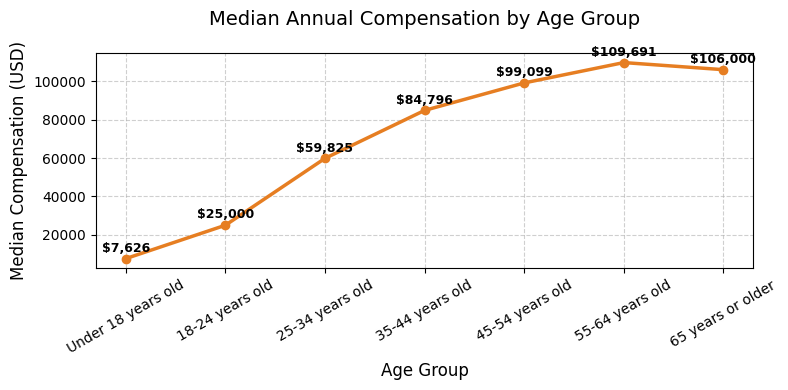

In [17]:
## Write your code here
# 4. Create the Line Chart
plt.figure(figsize=(8, 4))
plt.plot(median_comp_by_age['Age'], median_comp_by_age['ConvertedCompYearly'], 
         marker='o', linestyle='-', color='#e67e22', linewidth=2.5)
# 5. Customize the Visuals
plt.title('Median Annual Compensation by Age Group', pad= 20, fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Compensation (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
# Optional: Add data labels for clarity
for x, y in zip(median_comp_by_age['Age'], median_comp_by_age['ConvertedCompYearly']):
    plt.text(x, y + 2000, f'${y:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


In [18]:
# 1. Filter for the 25-45 age brackets
# Survey labels usually follow these standard 2026 formats:
target_ages = ['25-34 years old', '35-44 years old']
df_filtered = df[df['Age'].isin(target_ages)].copy()

In [19]:
# 2. Calculate Median Compensation for these groups
# We group by Age to show the trend specifically between these two major brackets
median_comp = df_filtered.groupby('Age')['ConvertedCompYearly'].median().reset_index()

In [20]:
# 3. Sort age groups to ensure the line flows correctly
age_order = ['25-34 years old', '35-44 years old']
median_comp['Age'] = pd.Categorical(median_comp['Age'], categories=age_order, ordered=True)
median_comp = median_comp.sort_values('Age')

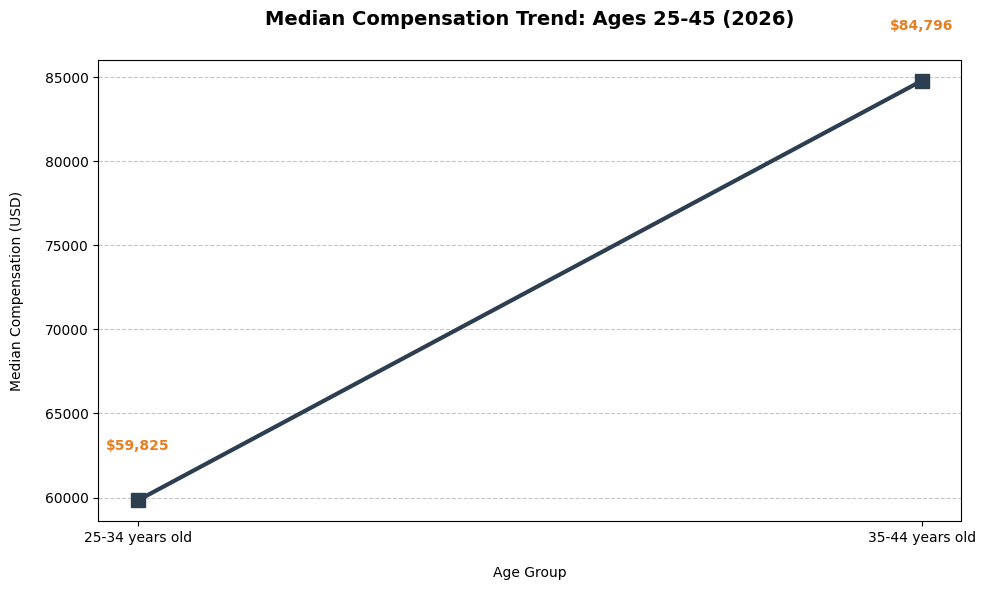

In [21]:
## Write your code here

# 4. Create the Line Chart
plt.figure(figsize=(10, 6))
plt.plot(median_comp['Age'], median_comp['ConvertedCompYearly'], 
         marker='s', linestyle='-', color='#2c3e50', linewidth=3, markersize=10)

# 5. Spacing and Formatting (Fixing title/picture overlap)
plt.title('Median Compensation Trend: Ages 25-45 (2026)', pad=25, fontsize=14, fontweight='bold')
plt.xlabel('Age Group', labelpad=15)
plt.ylabel('Median Compensation (USD)', labelpad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels for precision
for x, y in zip(median_comp['Age'], median_comp['ConvertedCompYearly']):
    plt.text(x, y + 3000, f'${y:,.0f}', ha='center', fontweight='bold', color='#e67e22')

# Final layout adjustment to prevent label clipping
plt.tight_layout()
plt.show()


### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


In [22]:
# 1. Prepare data
# Use 'YearsCodePro' for professional experience; drop missing values
df_sat = df[['YearsCodePro', 'JobSatPoints_6']].dropna()

In [23]:
# 2. Clean 'YearsCodePro'
# Convert to numeric, handling strings like 'Less than 1 year' or 'More than 50 years'
df_sat['YearsCodePro'] = pd.to_numeric(df_sat['YearsCodePro'], errors='coerce')
df_sat = df_sat.dropna(subset=['YearsCodePro'])

In [24]:
# 3. Bin experience into standard 2026 career stages
bins = [0, 5, 10, 20, 50]
labels = ['Early Career (0-5)', 'Mid-Career (6-10)', 'Experienced (11-20)', 'Senior+ (21+)']
df_sat['ExperienceLevel'] = pd.cut(df_sat['YearsCodePro'], bins=bins, labels=labels)

In [32]:
#df_sat['ExperienceLevel'].head()

In [28]:
# 4. Calculate Median Satisfaction
median_sat = df_sat.groupby('ExperienceLevel')['JobSatPoints_6'].median().reset_index()

In [31]:
#median_sat.head()

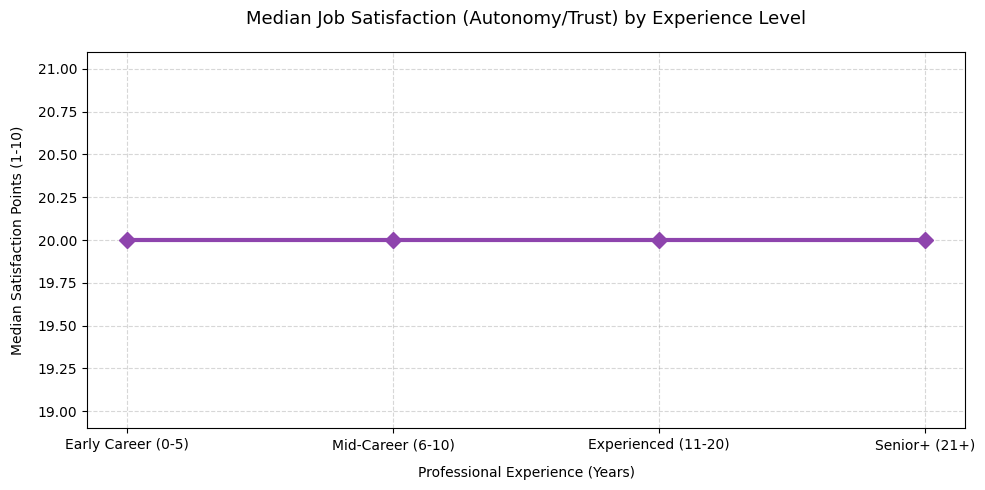

In [35]:
## Write your code here
# 5. Plot the Line Chart
plt.figure(figsize=(10, 5))
plt.plot(median_sat['ExperienceLevel'], median_sat['JobSatPoints_6'], 
         marker='D', linestyle='-', color='#8e44ad', linewidth=3, markersize=8)
# 6. Formatting & Spacing
plt.title('Median Job Satisfaction (Autonomy/Trust) by Experience Level', pad=20, fontsize=13)
plt.xlabel('Professional Experience (Years)', labelpad=10)
plt.ylabel('Median Satisfaction Points (1-10)', labelpad=10)
#plt.ylim(0, 10) # Satisfaction is typically on a 1-10 scale
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


In [36]:
# 1. Clean and Prepare Data
# Standard 2026 datasets use 'YearsCodePro' for professional years
df_comp = df[['YearsCodePro', 'ConvertedCompYearly']].dropna()

In [37]:
# Convert "Less than 1 year" to 0 and "More than 50 years" to 51
df_comp['YearsCodePro'] = df_comp['YearsCodePro'].replace('Less than 1 year', 0)
df_comp['YearsCodePro'] = df_comp['YearsCodePro'].replace('More than 50 years', 51)
df_comp['YearsCodePro'] = pd.to_numeric(df_comp['YearsCodePro'], errors='coerce')

In [38]:
# 2. Group by years and calculate Median
# Dropping NaNs ensures the line isn't broken by missing data points
median_comp = df_comp.groupby('YearsCodePro')['ConvertedCompYearly'].median().reset_index()

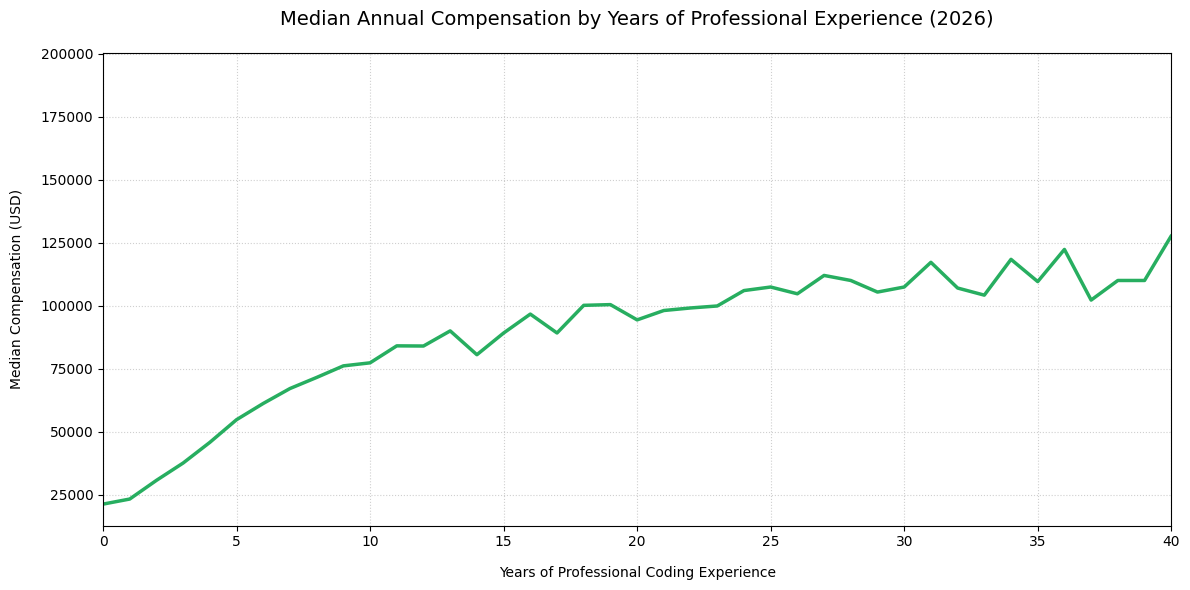

In [39]:
## Write your code here
# 3. Create the Line Chart
plt.figure(figsize=(12, 6))
plt.plot(median_comp['YearsCodePro'], median_comp['ConvertedCompYearly'], 
         color='#27ae60', linewidth=2.5, label='Median Salary')

# 4. Spacing and Formatting
plt.title('Median Annual Compensation by Years of Professional Experience (2026)', pad=20, fontsize=14)
plt.xlabel('Years of Professional Coding Experience', labelpad=12)
plt.ylabel('Median Compensation (USD)', labelpad=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Focus the X-axis on a standard 40-year career for better visibility
plt.xlim(0, 40)
# 5. Final Layout Adjustment
plt.tight_layout()
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


In [40]:
# 1. Prepare and Clean Data
# We use 'YearsCodePro' for professional years and 'JobSatPoints_6' for satisfaction
df_sat = df[['YearsCodePro', 'JobSatPoints_6']].dropna()

In [41]:
# Handle non-numeric survey strings (standard for 2026 data cleaning)
df_sat['YearsCodePro'] = df_sat['YearsCodePro'].replace('Less than 1 year', 0)
df_sat['YearsCodePro'] = df_sat['YearsCodePro'].replace('More than 50 years', 51)
df_sat['YearsCodePro'] = pd.to_numeric(df_sat['YearsCodePro'], errors='coerce')

In [48]:
#df_sat.head()

In [42]:
# 2. Group by Experience and calculate Median Satisfaction
# We drop NaNs to ensure a continuous line
median_sat = df_sat.groupby('YearsCodePro')['JobSatPoints_6'].median().reset_index()

In [47]:
#median_sat.head()

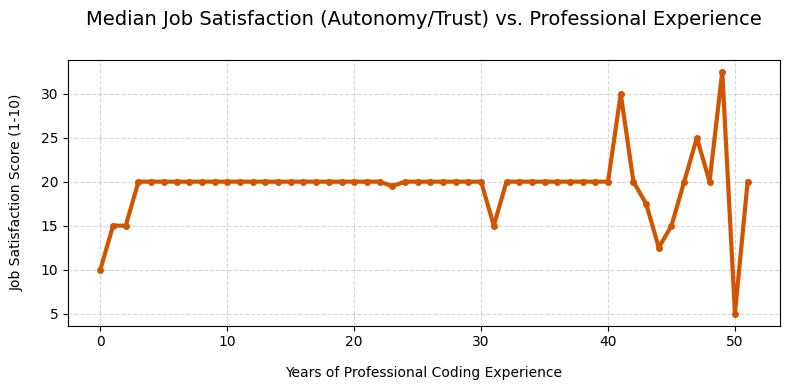

In [49]:
## Write your code here
# 3. Create the Line Chart
plt.figure(figsize=(8, 4))
plt.plot(median_sat['YearsCodePro'], median_sat['JobSatPoints_6'], 
         color='#d35400', linewidth=3, marker='o', markersize=4, label='Median Satisfaction')
# 4. Spacing and Formatting
# Use pad to prevent title overlap with the chart
plt.title('Median Job Satisfaction (Autonomy/Trust) vs. Professional Experience', pad=25, fontsize=14)
plt.xlabel('Years of Professional Coding Experience', labelpad=12)
plt.ylabel('Job Satisfaction Score (1-10)', labelpad=12)
# Set Y-axis to 1-10 to accurately represent the satisfaction scale
#plt.ylim(1, 10) 
plt.grid(True, linestyle='--', alpha=0.5)
# 5. Final Layout Adjustment
plt.tight_layout()
plt.show()

#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
